# Quantum Amplitude Estimation

## Lecture 6

### Last Time
1. Grover's Algorithm for Unstructured Search
2. Qiskit simulation of Grover search

### Today
1. Quantum Amplitude Estimation
2. QAE as an input to Grover's search
3. Qiskit simulation

In [1]:
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)

import math
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML, display

from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.circuit.library import UnitaryGate, StatePreparation
from qiskit.quantum_info import Statevector, Operator
from qiskit.visualization import plot_histogram

np.set_printoptions(precision=4, suppress=True)


def bits(j, n):
    return format(j, f'0{n}b')


def qft_circuit(n, do_swaps=True):
    qc = QuantumCircuit(n, name='QFT')
    for target in reversed(range(n)):
        qc.h(target)
        for control in reversed(range(target)):
            angle = np.pi / (2 ** (target - control))
            qc.cp(angle, control, target)
    if do_swaps:
        for q in range(n // 2):
            qc.swap(q, n - q - 1)
    return qc

# Grover Needs $M$ to Choose $k$

In Lecture 5, we saw that after $k$ Grover iterations, the state $|s \rangle = \cos\theta |\alpha\rangle + \sin\theta |\beta\rangle$ becomes

$$G^k|s\rangle
=\cos((2k+1)\theta)|\alpha\rangle
+\sin((2k+1)\theta)|\beta\rangle.$$

Recall that $|\alpha \rangle$ is an equal superposition of all $N-M$ unmarked states and $|\beta \rangle$ is an equal superposition of all $M$ marked states. $\theta$ itself is given by the relation

$$\sin \theta = \sqrt{\frac{M}{N}}.$$

The marked-state probability is maximized when

$$(2k+1)\theta\approx \frac{\pi}{2}.$$

So

$$k\approx\frac{\pi}{4\theta}.$$

## But $\theta$ depends on $M$

For a search space of size $N$ with $M$ marked states,

$$\sin\theta=\sqrt{\frac{M}{N}},$$

so when $M\ll N$,

$$\theta\approx\sqrt{\frac{M}{N}}.$$

That gives the familiar iteration count

$$k_{\text{opt}}\approx \frac{\pi}{4}\sqrt{\frac{N}{M}}.$$

If $M$ is unknown, then the right rotation angle is unknown too. Run too few iterations and the marked amplitude stays small; run too many and Grover over-rotates.

# Amplitude Estimation

Grover is the special case where we start with a uniform superposition and amplify the amplitudes of marked basis states.

More generally, suppose a circuit $A$ prepares

$$A|0\rangle=\sqrt{1-a}\,|\psi_0\rangle|0\rangle
+\sqrt a\,|\psi_1\rangle|1\rangle.$$

The last qubit marks the marked subspace.

The number

$$a$$

is the marked probability, or **amplitude squared**, that we want to estimate

## The amplitude angle

Write

$$a=\sin^2\theta.$$

Then

$$A|0\rangle=\cos\theta\,|\text{unmarked}\rangle+\sin\theta\,|\text{marked}\rangle.$$

Amplitude amplification builds a Grover operator $Q$ from two reflections:

1. reflect around the marked/unmarked split,
2. reflect around the prepared state $A|0\rangle$.

Just like Grover search, $Q$ rotates by angle $2\theta$ in the two-dimensional plane.

## Building the QAE Grover operator

Start with

$$A|0\rangle=\cos\theta|\text{unmarked}\rangle+\sin\theta|\text{marked}\rangle.$$

Define a reflection that flips the marked subspace:

$$S_{\text{marked}}|\text{unmarked}\rangle=|\text{unmarked}\rangle,$$

$$S_{\text{marked}}|\text{marked}\rangle=-|\text{marked}\rangle.$$

Define a reflection about the initial all-zero state:

$$S_0=I-2|0\rangle\langle 0|.$$

Then a standard amplitude-estimation Grover operator is

$$Q=-A S_0 A^\dagger S_{\text{marked}}.$$

The Grover operator $G = D O_f$ from last lecture is the special case when $S_{\text{marked}} = O_f$ and $A = H^{\otimes n}$.

## Why $Q$ has a phase to estimate

In the two-dimensional marked/unmarked plane, write the prepared state as

$$|\psi\rangle=\cos\theta|\text{unmarked}\rangle+\sin\theta|\text{marked}\rangle.$$

The Grover operator $Q$ is a rotation by angle $2\theta$ in this plane.

A real two-dimensional rotation has two complex eigenvalues:

$$e^{+2i\theta}\qquad\text{and}\qquad e^{-2i\theta}.$$

Phase estimation expects eigenvalues in the form

$$e^{2\pi i\phi}.$$

So the two possible phases are

$$\phi_+=\frac{\theta}{\pi},$$

and

$$\phi_-=-\frac{\theta}{\pi}\pmod 1=1-\frac{\theta}{\pi}.$$

The second angle $\phi_-$ is just the negative rotation direction written as a number between $0$ and $1$.

## From QAE measurement to amplitude

Use $m$ evaluation qubits. Phase estimation returns an integer $y$ with

$$\phi=\frac{y}{2^m}.$$

Ideally, $z$ is close to one of the two phase fractions:

$$\phi\approx \frac{\theta}{\pi}$$

or

$$\phi\approx 1-\frac{\theta}{\pi}.$$

Both give the same amplitude because

$$\sin^2(\pi(1-\phi))=\sin^2(\pi \phi).$$

So the post-processing rule is

$$\widehat a=\sin^2(\pi \phi)=\sin^2\left(\pi\frac{y}{2^m}\right).$$

## Quantum amplitude estimation

Quantum amplitude estimation uses phase estimation on the Grover operator $Q$.

The prepared state

$$|\psi\rangle=\cos\theta|\text{unmarked}\rangle+\sin\theta|\text{marked}\rangle$$

is not itself an eigenstate of $Q$. In this two-dimensional plane, the eigenstates are

$$|\psi_{+}\rangle=\frac{1}{\sqrt2}\left(|\text{unmarked}\rangle-i|\text{marked}\rangle\right),$$

$$|\psi_{-}\rangle=\frac{1}{\sqrt2}\left(|\text{unmarked}\rangle+i|\text{marked}\rangle\right).$$

Their eigenphases encode the amplitude angle:

$$Q|\psi_{+}\rangle=e^{+2i\theta}|\psi_{+}\rangle,$$

$$Q|\psi_{-}\rangle=e^{-2i\theta}|\psi_{-}\rangle.$$

The prepared state $|\psi\rangle=\cos\theta|\text{unmarked}\rangle+\sin\theta|\text{marked}\rangle$ is an equal-weight superposition of these eigenstates:

$$|\psi\rangle=\frac{1}{\sqrt2}\left(e^{i\theta}|\psi_+\rangle+e^{-i\theta}|\psi_-\rangle\right).$$

So QPE returns one of the two phases.

Because QPE reports phases modulo $1$, the negative phase appears as

$$-\frac{\theta}{\pi}\pmod 1=1-\frac{\theta}{\pi}.$$

Either measured phase gives

$$a=\sin^2\theta.$$

## Why QAE matters

Many useful quantities can be written as probabilities or expectations.

Classical Monte Carlo estimates an expectation with error roughly

$$O\left(\frac{1}{\sqrt S}\right)$$

using $S$ samples.

Ideal QAE can achieve error roughly

$$O\left(\frac{1}{T}\right)$$

using $T$ applications of the state-preparation and Grover operators.

That quadratic improvement is why QAE is often discussed for finance, risk analysis, counting, reliability estimation, and simulation problems.

# QAE for Grover with Unknown $M$

In Grover's algorithm, the best iteration count depends on the number of marked inputs:

$$k_{\text{opt}}\approx \frac{\pi}{4}\sqrt{\frac{N}{M}}.$$

But what if we do not know $M$?

The marked fraction is

$$a=\frac{M}{N}.$$

That is exactly an amplitude-estimation problem.

If QAE estimates $a$, then we estimate

$$\widehat M=N\widehat a,$$

and choose approximately

$$\widehat k_{\text{opt}}\approx \frac{\pi}{4}\frac{1}{\sqrt{\widehat a}}.$$

## How to turn Grover into counting

Use the same search preparation as Grover:

$$A|0\rangle=H^{\otimes n}|0\rangle=\frac{1}{\sqrt N}\sum_x |x\rangle.$$

The marked subspace is the span of the marked states.

Therefore

$$a=\Pr[\text{marked}]=\frac{M}{N}.$$

QAE estimates this probability without first knowing $M$.

This is often called **quantum counting**.

## Example setup

We reuse the earlier Grover search space:

$$N=16.$$

There are secretly two marked states:

$$|0110\rangle,\qquad |1011\rangle.$$

So the true values are

$$M=2,$$

and

$$a=\frac{M}{N}=\frac{2}{16}=0.125.$$

In the simulation below, QAE only sees the oracle. It estimates $a$, then infers $M$.

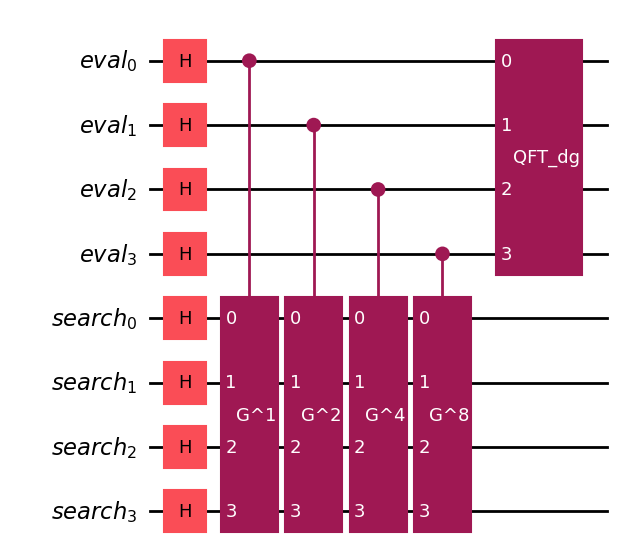

In [7]:
def grover_matrix_for_marked(n, marked_bitstrings):
    dim = 2 ** n

    oracle_diagonal = np.ones(dim, dtype=complex)
    for bitstring in marked_bitstrings:
        oracle_diagonal[int(bitstring, 2)] = -1
    oracle_matrix = np.diag(oracle_diagonal)

    uniform = np.ones(dim, dtype=complex) / np.sqrt(dim)
    diffuser_matrix = 2 * np.outer(uniform, uniform.conj()) - np.eye(dim)

    return diffuser_matrix @ oracle_matrix


def grover_counting_qae_circuit(n, marked_bitstrings, m_eval=7):
    grover_matrix = grover_matrix_for_marked(n, marked_bitstrings)

    eval_register = QuantumRegister(m_eval, name='eval')
    search_register = QuantumRegister(n, name='search')
    qc = QuantumCircuit(eval_register, search_register)

    # Phase-estimation register.
    qc.h(eval_register)

    # A = H^n prepares the uniform search state.
    qc.h(search_register)

    for j, q in enumerate(eval_register):
        G_power = np.linalg.matrix_power(grover_matrix, 2 ** j)
        controlled_G_power = UnitaryGate(G_power, label=f'G^{2 ** j}').control(1)
        qc.append(controlled_G_power, [q] + list(search_register))

    qc.append(qft_circuit(m_eval).inverse(), eval_register)
    return qc


counting_demo = grover_counting_qae_circuit(4, marked, m_eval=4)
counting_demo.draw(output='mpl')

In [8]:
m_eval_counting = 7
counting_qc = grover_counting_qae_circuit(4, marked, m_eval=m_eval_counting)
counting_state = Statevector.from_instruction(counting_qc)
counting_probabilities = counting_state.probabilities_dict(qargs=range(m_eval_counting))

N_search = 2 ** 4
true_M = len(marked)
true_a = true_M / N_search

def marked_fraction_from_bits(bitstring, m_eval):
    y = int(bitstring, 2)
    z = y / (2 ** m_eval)
    a_hat = np.sin(np.pi * z) ** 2
    M_hat = N_search * a_hat
    if a_hat > 0:
        k_hat = np.pi / (4 * np.sqrt(a_hat))
    else:
        k_hat = np.inf
    return y, z, a_hat, M_hat, k_hat

top_counting = sorted(counting_probabilities.items(), key=lambda item: item[1], reverse=True)[:8]
print(f'True marked count M = {true_M}')
print(f'True marked fraction a = M/N = {true_a:.5f}')
print('\nMost likely QAE outcomes for quantum counting:')
for bitstring, probability in top_counting:
    y, z, a_hat, M_hat, k_hat = marked_fraction_from_bits(bitstring, m_eval_counting)
    print(
        f'bits={bitstring}, y={y:3d}, probability={probability:.4f}, '
        f'a_hat={a_hat:.5f}, M_hat={M_hat:.3f}, k_hat≈{k_hat:.2f}'
    )

best_counting_bits = top_counting[0][0]
_, _, best_a_hat, best_M_hat, best_k_hat = marked_fraction_from_bits(best_counting_bits, m_eval_counting)
print(f'\nBest estimate: M_hat = {best_M_hat:.3f}')
print(f'Recommended Grover iterations: round({best_k_hat:.2f}) = {round(best_k_hat)}')

True marked count M = 2
True marked fraction a = M/N = 0.12500

Most likely QAE outcomes for quantum counting:
bits=0001111, y= 15, probability=0.3862, a_hat=0.12952, M_hat=2.072, k_hat≈2.18
bits=1110001, y=113, probability=0.3862, a_hat=0.12952, M_hat=2.072, k_hat≈2.18
bits=0001110, y= 14, probability=0.0565, a_hat=0.11349, M_hat=1.816, k_hat≈2.33
bits=1110010, y=114, probability=0.0565, a_hat=0.11349, M_hat=1.816, k_hat≈2.33
bits=0010000, y= 16, probability=0.0182, a_hat=0.14645, M_hat=2.343, k_hat≈2.05
bits=1110000, y=112, probability=0.0182, a_hat=0.14645, M_hat=2.343, k_hat≈2.05
bits=0001101, y= 13, probability=0.0100, a_hat=0.09840, M_hat=1.574, k_hat≈2.50
bits=1110011, y=115, probability=0.0100, a_hat=0.09840, M_hat=1.574, k_hat≈2.50

Best estimate: M_hat = 2.072
Recommended Grover iterations: round(2.18) = 2


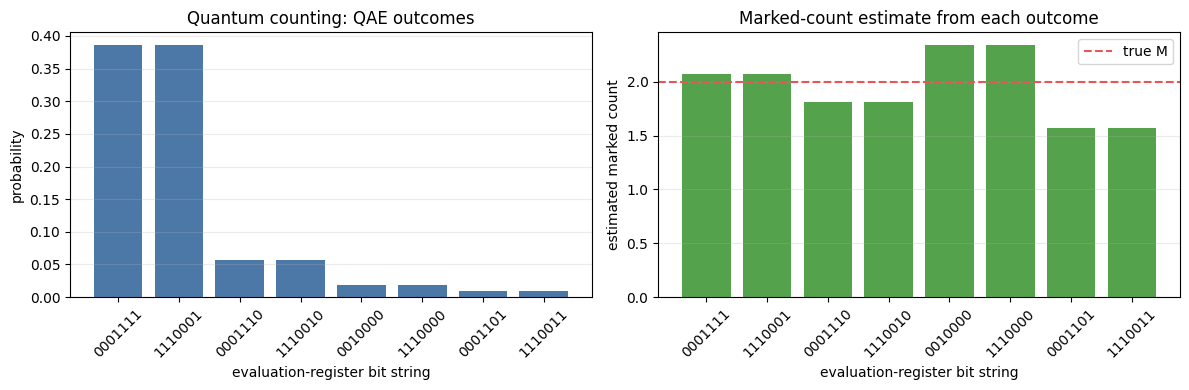

In [9]:
counting_labels = [bits for bits, _ in top_counting]
counting_values = [prob for _, prob in top_counting]
counting_M_estimates = [marked_fraction_from_bits(bits, m_eval_counting)[3] for bits, _ in top_counting]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(counting_labels, counting_values, color='#4c78a8')
axes[0].set_title('Quantum counting: QAE outcomes')
axes[0].set_xlabel('evaluation-register bit string')
axes[0].set_ylabel('probability')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', alpha=0.25)

axes[1].bar(counting_labels, counting_M_estimates, color='#54a24b')
axes[1].axhline(true_M, color='#e45756', linestyle='--', label='true M')
axes[1].set_title('Marked-count estimate from each outcome')
axes[1].set_xlabel('evaluation-register bit string')
axes[1].set_ylabel('estimated marked count')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend()
axes[1].grid(axis='y', alpha=0.25)
plt.tight_layout()

## What quantum counting gives Grover

For this example, QAE estimates

$$M\approx 2.$$

Then Grover can choose

$$k\approx\frac{\pi}{4}\sqrt{\frac{16}{2}}\approx 2.22,$$

so we run about $2$ Grover iterations.

That matches the earlier simulation, where two iterations gave marked probability about $0.945$.

The bigger idea:

> QAE can be used as a counting subroutine that tells Grover how long to rotate when the number of marked inputs is unknown.

## Complexity with counting first

Known $M$ Grover search costs

$$k = \frac{\pi}{4} \sqrt{\frac{N}{M}}$$

oracle calls.

If $M$ is unknown, quantum counting estimates the angle

$$\theta=\arcsin\sqrt{\frac{M}{N}}$$

using QAE. To choose $k$ well, we only need a constant-relative estimate of $\theta$, not the exact integer $M$.

Since QAE estimates $\theta$ to accuracy $O(1/T)$ after $T$ Grover-operator uses, take

$$T=O\left(\frac{1}{\theta}\right)=O\left(\sqrt{\frac{N}{M}}\right).$$

Then the final Grover search is another $O\left(\sqrt{N/M}\right)$ calls.

Total cost stays

$$O\left(\sqrt{\frac{N}{M}}\right),$$

with larger constants and more circuit structure. It is still quadratically better than classical brute force search, which costs $O(N/M)$ checks.

## When QAE is useful

QAE is most useful when the problem already looks like Monte Carlo:

$$\text{estimate }\mathbb E[f(X)]\text{ or }\Pr[\text{event}].$$

Examples:

1. count how many inputs satisfy a condition,
2. estimate risk or expected loss,
3. price a derivative (Phys. Rev. A 98, 022321),
4. estimate a tail probability or another rare event,
5. estimate an integral.

The catch is that QAE needs coherent access to the model through $A$, $A^\dagger$, and controlled powers of the Grover operator $Q$.

So QAE is useful when state preparation is efficient and repeated sampling would be expensive.

# QAE Example: Estimating Expected Loss

Suppose a tiny portfolio has eight equally likely scenarios.

The losses, measured in dollars, are

| Scenario | Loss |
|---:|---:|
| 0 | 2 |
| 1 | 5 |
| 2 | 8 |
| 3 | 12 |
| 4 | 18 |
| 5 | 25 |
| 6 | 35 |
| 7 | 50 |

The true expected loss is

$$\mathbb E[L]=19.375.$$

We will estimate it using QAE.

## Encoding the expected value as an amplitude

Let $L_{\max}=100$ and define normalized losses

$$\ell_x=\frac{L_x}{L_{\max}}.$$

Build a circuit $A$ that prepares

$$A|0\rangle
=\frac{1}{\sqrt 8}\sum_{x=0}^7 |x\rangle
\left(\sqrt{1-\ell_x}|0\rangle+\sqrt{\ell_x}|1\rangle\right).$$

The probability of measuring the objective qubit as $1$ is

$$a=\frac{1}{8}\sum_{x=0}^7 \ell_x
=\frac{\mathbb E[L]}{L_{\max}}.$$

So once QAE estimates $a$, we multiply by $L_{\max}$ to estimate $\mathbb E[L]$.

## QAE circuit structure

The QAE circuit has three conceptual parts:

1. Prepare the model state using $A$.
2. Run phase estimation on the Grover operator $Q$.
3. Convert the measured phase estimate into

$$\widehat a=\sin^2\left(\pi\frac{y}{2^m}\right).$$

Then

$$\widehat{\mathbb E[L]}=L_{\max}\widehat a.$$

Here $m$ is the number of evaluation qubits used by phase estimation.

In [10]:
def expected_loss_state_preparation(losses, probabilities=None, loss_max=100):
    losses = np.asarray(losses, dtype=float)
    normalized_losses = losses / loss_max
    n_data = int(np.log2(len(losses)))
    if 2 ** n_data != len(losses):
        raise ValueError('The number of scenarios must be a power of 2.')

    if probabilities is None:
        probabilities = np.ones(len(losses)) / len(losses)
    probabilities = np.asarray(probabilities, dtype=float)

    total_qubits = n_data + 1
    objective_qubit = n_data
    state = np.zeros(2 ** total_qubits, dtype=complex)

    for x, (probability, loss_fraction) in enumerate(zip(probabilities, normalized_losses)):
        state[x] = np.sqrt(probability) * np.sqrt(1 - loss_fraction)
        state[x + (1 << objective_qubit)] = np.sqrt(probability) * np.sqrt(loss_fraction)

    A = QuantumCircuit(total_qubits, name='A')
    A.append(StatePreparation(state), range(total_qubits))
    return A, state


def grover_operator_for_amplitude_estimation(A, objective_qubit):
    A_matrix = Operator(A).data
    dim = A_matrix.shape[0]

    # S_good flips the phase when the objective qubit is |1>.
    S_good = np.eye(dim, dtype=complex)
    for basis_index in range(dim):
        if (basis_index >> objective_qubit) & 1:
            S_good[basis_index, basis_index] = -1

    # S_zero flips the all-zero state. The global minus sign gives the standard QAE phase convention.
    S_zero = np.eye(dim, dtype=complex)
    S_zero[0, 0] = -1

    return -A_matrix @ S_zero @ A_matrix.conj().T @ S_good


def qae_circuit_for_expected_loss(losses, probabilities=None, loss_max=100, m_eval=8):
    A, _ = expected_loss_state_preparation(losses, probabilities, loss_max)
    n_model = A.num_qubits
    objective_qubit = n_model - 1
    Q_matrix = grover_operator_for_amplitude_estimation(A, objective_qubit)

    eval_register = QuantumRegister(m_eval, name='eval')
    model_register = QuantumRegister(n_model, name='model')
    qc = QuantumCircuit(eval_register, model_register)

    qc.h(eval_register)
    qc.append(A, model_register)

    for j, q in enumerate(eval_register):
        Q_power = np.linalg.matrix_power(Q_matrix, 2 ** j)
        controlled_Q_power = UnitaryGate(Q_power, label=f'Q^{2 ** j}').control(1)
        qc.append(controlled_Q_power, [q] + list(model_register))

    qc.append(qft_circuit(m_eval).inverse(), eval_register)
    return qc

True expected loss = $19.375
True amplitude a = E[L]/L_max = 0.19375


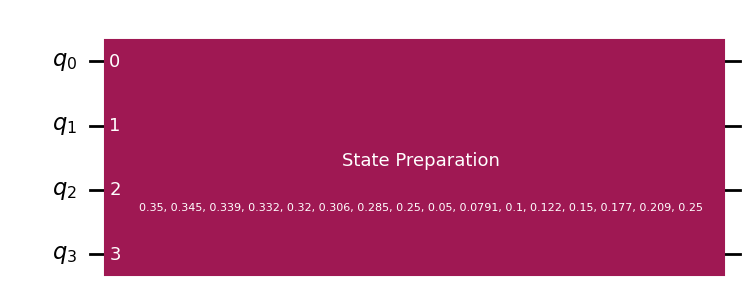

In [11]:
losses = np.array([2, 5, 8, 12, 18, 25, 35, 50], dtype=float)
loss_max = 100
true_expected_loss = float(np.mean(losses))
true_amplitude = true_expected_loss / loss_max

print(f'True expected loss = ${true_expected_loss:.3f}')
print(f'True amplitude a = E[L]/L_max = {true_amplitude:.5f}')

A_loss, _ = expected_loss_state_preparation(losses, loss_max=loss_max)
A_loss.draw(output='mpl')

In [12]:
m_eval = 8
qae_qc = qae_circuit_for_expected_loss(losses, loss_max=loss_max, m_eval=m_eval)
state = Statevector.from_instruction(qae_qc)
phase_probabilities = state.probabilities_dict(qargs=range(m_eval))

def amplitude_estimate_from_bits(bitstring):
    y = int(bitstring, 2)
    phase_fraction = y / (2 ** m_eval)
    amplitude = np.sin(np.pi * phase_fraction) ** 2
    return y, phase_fraction, amplitude

top_qae = sorted(phase_probabilities.items(), key=lambda item: item[1], reverse=True)[:10]
print('Most likely QAE measurement outcomes:')
for bitstring, probability in top_qae:
    y, phase_fraction, amplitude = amplitude_estimate_from_bits(bitstring)
    expected_loss_estimate = loss_max * amplitude
    print(
        f'bits={bitstring}, y={y:3d}, probability={probability:.4f}, '
        f'a_hat={amplitude:.5f}, E[L]_hat=${expected_loss_estimate:.3f}'
    )

best_bitstring = top_qae[0][0]
_, _, best_amplitude = amplitude_estimate_from_bits(best_bitstring)
best_expected_loss = loss_max * best_amplitude
print(f'\nBest estimate from most likely outcome: ${best_expected_loss:.3f}')
print(f'Absolute error: ${abs(best_expected_loss - true_expected_loss):.3f}')

Most likely QAE measurement outcomes:
bits=11011011, y=219, probability=0.4682, a_hat=0.19238, E[L]_hat=$19.238
bits=00100101, y= 37, probability=0.4682, a_hat=0.19238, E[L]_hat=$19.238
bits=11011010, y=218, probability=0.0126, a_hat=0.20215, E[L]_hat=$20.215
bits=00100110, y= 38, probability=0.0126, a_hat=0.20215, E[L]_hat=$20.215
bits=11011100, y=220, probability=0.0072, a_hat=0.18280, E[L]_hat=$18.280
bits=00100100, y= 36, probability=0.0072, a_hat=0.18280, E[L]_hat=$18.280
bits=11011001, y=217, probability=0.0027, a_hat=0.21210, E[L]_hat=$21.210
bits=00100111, y= 39, probability=0.0027, a_hat=0.21210, E[L]_hat=$21.210
bits=11011101, y=221, probability=0.0020, a_hat=0.17341, E[L]_hat=$17.341
bits=00100011, y= 35, probability=0.0020, a_hat=0.17341, E[L]_hat=$17.341

Best estimate from most likely outcome: $19.238
Absolute error: $0.137


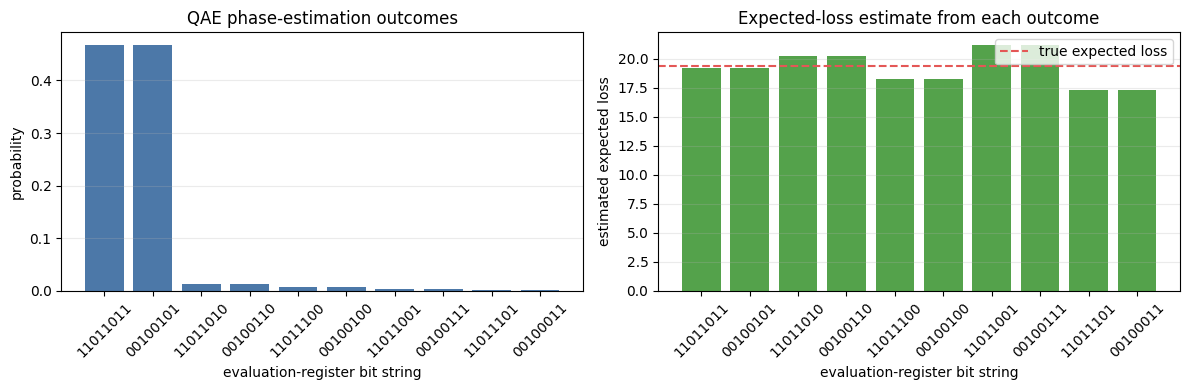

In [13]:
plot_items = top_qae
labels = [item[0] for item in plot_items]
values = [item[1] for item in plot_items]
estimates = [loss_max * amplitude_estimate_from_bits(bitstring)[2] for bitstring, _ in plot_items]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(labels, values, color='#4c78a8')
axes[0].set_title('QAE phase-estimation outcomes')
axes[0].set_xlabel('evaluation-register bit string')
axes[0].set_ylabel('probability')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', alpha=0.25)

axes[1].bar(labels, estimates, color='#54a24b')
axes[1].axhline(true_expected_loss, color='#e45756', linestyle='--', label='true expected loss')
axes[1].set_title('Expected-loss estimate from each outcome')
axes[1].set_xlabel('evaluation-register bit string')
axes[1].set_ylabel('estimated expected loss')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend()
axes[1].grid(axis='y', alpha=0.25)
plt.tight_layout()

## What the QAE simulation shows

The true value is

$$\mathbb E[L]=19.375.$$

With $m=8$ evaluation qubits, the most likely QAE outcome gives an estimate close to this value.

The important conceptual point is the workflow:

$$\text{expected value}\to\text{amplitude}\to\text{phase}\to\text{measurement}\to\text{estimate}.$$

QAE is useful when:

1. the quantity can be encoded as an amplitude,
2. state preparation and its inverse are not too expensive,
3. oracle/Grover calls are the bottleneck,
4. we need better scaling than classical Monte Carlo.